# Black-Body Radiation Modelling and Temperature Estimation

This notebook explores the numerical modelling of black-body radiation using Python.

The analysis investigates:

- Planck's law and the shape of black-body spectra
- how temperature affects spectral intensity and peak frequency
- numerical determination of the peak-emission frequency
- numerical integration of the spectrum and comparison with the Stefan-Boltzmann law
- recovery of black-body temperature from synthetic noisy observations
- residual analysis and uncertainty estimation

The project demonstrates the application of numerical methods, optimisation and parameter estimation to a fundamental problem in astrophysics.

In [90]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

from scipy.constants import Stefan_Boltzmann as sigma


# Make the project source code importable from this notebook.
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.blackbody import (
    peak_frequency,
    planck_radiance,
    total_luminosity_numerical,
)

from src.fitting import (
    fit_blackbody_spectrum,
    scaled_planck_radiance,
)


print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\amitd\Documents\GitHub\blackbody-radiation-modelling


## 1. Black-body spectra at different temperatures

Planck's law describes the spectral radiance emitted by an ideal black body as a function of frequency and temperature.

For several representative stellar temperatures, the spectra can be calculated numerically to examine how increasing temperature affects both the emitted intensity and the location of the spectral peak.

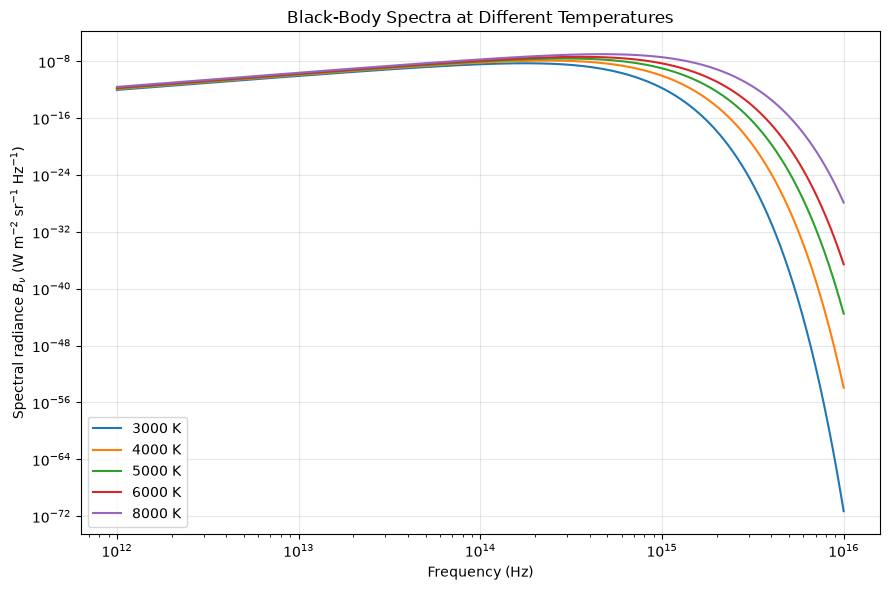

In [91]:
# Frequency range spanning infrared to ultraviolet frequencies
frequencies = np.logspace(12, 16, 1000)

# Representative stellar temperatures in kelvin
temperatures = [3000, 4000, 5000, 6000, 8000]


plt.figure(figsize=(9, 6))

for temperature in temperatures:
    radiance = planck_radiance(
        frequencies,
        temperature,
    )

    plt.plot(
        frequencies,
        radiance,
        label=f"{temperature} K",
    )


plt.xscale("log")
plt.yscale("log")

plt.xlabel("Frequency (Hz)")
plt.ylabel(r"Spectral radiance $B_\nu$ (W m$^{-2}$ sr$^{-1}$ Hz$^{-1}$)")
plt.title("Black-Body Spectra at Different Temperatures")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "blackbody_spectra.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

## 2. Peak frequency and temperature

The frequency at which a black-body spectrum reaches its maximum depends on temperature.

For a spectrum expressed in frequency space, the peak satisfies

\[
\nu_{\mathrm{peak}} \propto T.
\]

The numerical optimisation routine implemented in this project can be used to determine the peak frequency independently for each temperature and test this proportionality.

In [92]:
peak_frequencies = []

for temperature in temperatures:
    nu_peak = peak_frequency(temperature)
    peak_frequencies.append(nu_peak)

    print(
        f"T = {temperature:4d} K  "
        f"nu_peak = {nu_peak:.3e} Hz  "
        f"nu_peak / T = {nu_peak / temperature:.3e} Hz K^-1"
    )

T = 3000 K  nu_peak = 1.764e+14 Hz  nu_peak / T = 5.879e+10 Hz K^-1
T = 4000 K  nu_peak = 2.352e+14 Hz  nu_peak / T = 5.879e+10 Hz K^-1
T = 5000 K  nu_peak = 2.939e+14 Hz  nu_peak / T = 5.879e+10 Hz K^-1
T = 6000 K  nu_peak = 3.527e+14 Hz  nu_peak / T = 5.879e+10 Hz K^-1
T = 8000 K  nu_peak = 4.703e+14 Hz  nu_peak / T = 5.879e+10 Hz K^-1


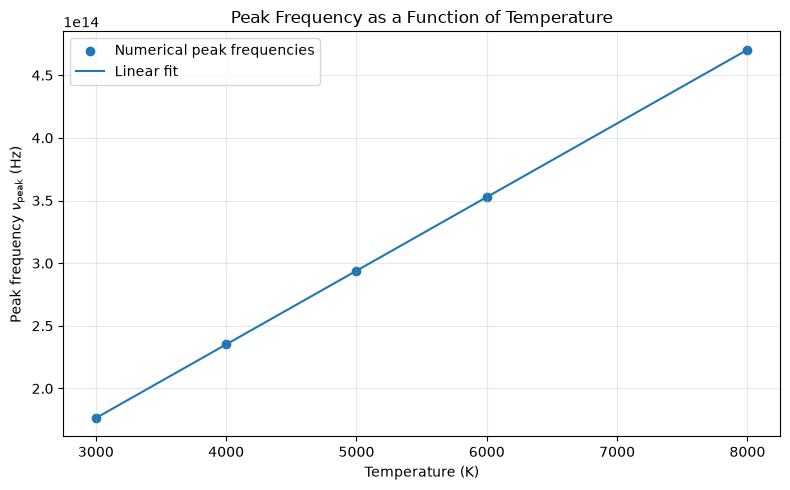

Fitted slope: 5.8789e+10 Hz K^-1
Fitted intercept: 6.5997e+06 Hz


In [93]:
peak_frequencies = np.array(peak_frequencies)

# Fit a straight line through the numerical results
slope, intercept = np.polyfit(
    temperatures,
    peak_frequencies,
    1,
)

temperature_grid = np.linspace(
    min(temperatures),
    max(temperatures),
    200,
)

fitted_peaks = slope * temperature_grid + intercept


plt.figure(figsize=(8, 5))

plt.scatter(
    temperatures,
    peak_frequencies,
    label="Numerical peak frequencies",
)

plt.plot(
    temperature_grid,
    fitted_peaks,
    label="Linear fit",
)

plt.xlabel("Temperature (K)")
plt.ylabel(r"Peak frequency $\nu_{\mathrm{peak}}$ (Hz)")
plt.title("Peak Frequency as a Function of Temperature")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


print(f"Fitted slope: {slope:.4e} Hz K^-1")
print(f"Fitted intercept: {intercept:.4e} Hz")

In [94]:
from scipy.constants import Boltzmann as k_B
from scipy.constants import Planck as h


theoretical_slope = 2.821439 * k_B / h

percentage_difference = (
    abs(slope - theoretical_slope)
    / theoretical_slope
    * 100
)


print(
    f"Numerical slope:   {slope:.6e} Hz K^-1"
)

print(
    f"Theoretical slope: {theoretical_slope:.6e} Hz K^-1"
)

print(
    f"Percentage difference: {percentage_difference:.4f}%"
)

Numerical slope:   5.878926e+10 Hz K^-1
Theoretical slope: 5.878925e+10 Hz K^-1
Percentage difference: 0.0000%


### Interpretation

The numerically determined peak frequencies increase linearly with temperature.

The fitted gradient is consistent with the theoretical frequency-space form of Wien's displacement relation,

\[
\nu_{\mathrm{peak}}
=
\frac{2.821439\,k_B}{h}T.
\]

The close agreement between the numerical and theoretical results provides a validation of both the Planck-spectrum implementation and the peak-frequency optimisation routine.

Astrophysically, this relationship explains why hotter stellar photospheres have spectral energy distributions shifted toward higher frequencies.

## 3. Numerical integration and the Stefan–Boltzmann law

The total luminosity of an ideal spherical black body is given analytically by the Stefan–Boltzmann law,

\[
L = 4\pi R^2 \sigma T^4,
\]

where \(R\) is the radius of the emitting body, \(T\) is its temperature and \(\sigma\) is the Stefan–Boltzmann constant.

The Planck spectrum can also be integrated numerically over frequency to obtain the total luminosity. Comparing the numerical result with the analytical Stefan–Boltzmann prediction provides an independent validation of the spectral model.

In [95]:
radius = 1.0  # metres

temperatures_array = np.array(
    temperatures,
    dtype=float,
)

numerical_luminosities = np.array(
    [
        total_luminosity_numerical(
            radius,
            temperature,
        )
        for temperature in temperatures_array
    ]
)

analytical_luminosities = (
    4
    * np.pi
    * radius**2
    * sigma
    * temperatures_array**4
)

percentage_differences = (
    np.abs(
        numerical_luminosities
        - analytical_luminosities
    )
    / analytical_luminosities
    * 100
)


for temperature, numerical, analytical, difference in zip(
    temperatures_array,
    numerical_luminosities,
    analytical_luminosities,
    percentage_differences,
):
    print(
        f"T = {temperature:4.0f} K | "
        f"Numerical = {numerical:.4e} W | "
        f"Analytical = {analytical:.4e} W | "
        f"Difference = {difference:.4f}%"
    )

T = 3000 K | Numerical = 5.7717e+07 W | Analytical = 5.7717e+07 W | Difference = 0.0000%
T = 4000 K | Numerical = 1.8242e+08 W | Analytical = 1.8242e+08 W | Difference = 0.0000%
T = 5000 K | Numerical = 4.4535e+08 W | Analytical = 4.4535e+08 W | Difference = 0.0000%
T = 6000 K | Numerical = 9.2348e+08 W | Analytical = 9.2348e+08 W | Difference = 0.0000%
T = 8000 K | Numerical = 2.9186e+09 W | Analytical = 2.9186e+09 W | Difference = 0.0000%


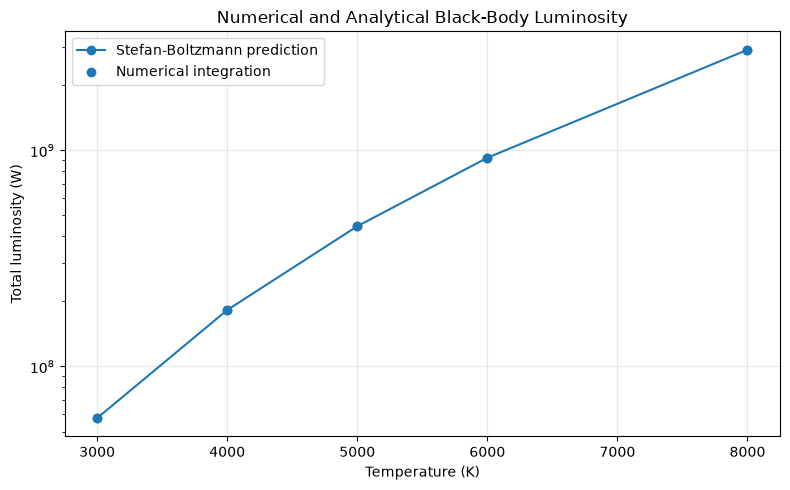

In [96]:
plt.figure(figsize=(8, 5))

plt.plot(
    temperatures_array,
    analytical_luminosities,
    marker="o",
    label="Stefan-Boltzmann prediction",
)

plt.scatter(
    temperatures_array,
    numerical_luminosities,
    label="Numerical integration",
)

plt.xlabel("Temperature (K)")
plt.ylabel("Total luminosity (W)")
plt.title("Numerical and Analytical Black-Body Luminosity")

plt.yscale("log")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

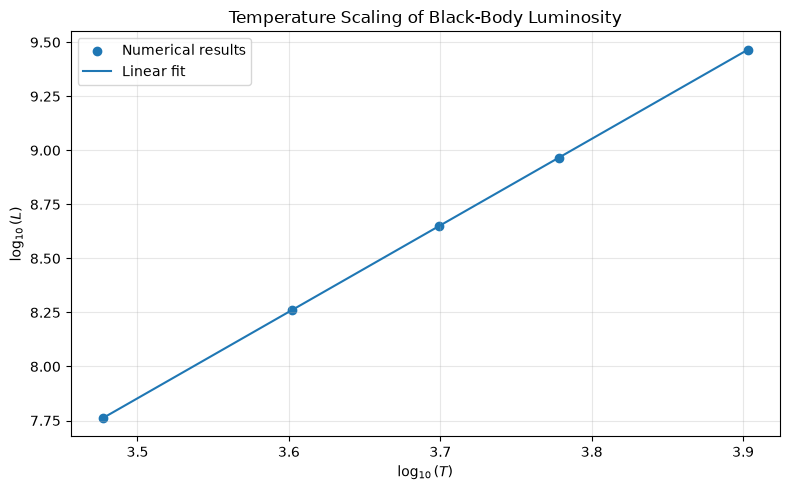

Recovered power-law exponent: 4.000000


In [97]:
log_temperature = np.log10(
    temperatures_array
)

log_luminosity = np.log10(
    numerical_luminosities
)

power_law_slope, power_law_intercept = np.polyfit(
    log_temperature,
    log_luminosity,
    1,
)


plt.figure(figsize=(8, 5))

plt.scatter(
    log_temperature,
    log_luminosity,
    label="Numerical results",
)

plt.plot(
    log_temperature,
    power_law_slope * log_temperature
    + power_law_intercept,
    label="Linear fit",
)

plt.xlabel(r"$\log_{10}(T)$")
plt.ylabel(r"$\log_{10}(L)$")
plt.title("Temperature Scaling of Black-Body Luminosity")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


print(
    f"Recovered power-law exponent: "
    f"{power_law_slope:.6f}"
)

### Interpretation

The luminosities obtained by numerically integrating the Planck spectrum closely reproduce those predicted by the Stefan–Boltzmann law.

A log-log fit to the numerical results also recovers a power-law exponent close to 4, consistent with

\[
L \propto T^4.
\]

This agreement provides an independent validation of the numerical Planck-spectrum implementation and demonstrates how the Stefan–Boltzmann law emerges from integration over the full black-body spectrum.

The strong temperature dependence is astrophysically important: relatively modest changes in stellar effective temperature can produce large changes in the total radiative output of a star of fixed radius.

## 4. Recovering temperature from synthetic observations

In observational astrophysics, the temperature of a radiating source is not known in advance and must be inferred from measured spectral data.

To test the fitting routine, a synthetic black-body spectrum is generated at a known temperature and then perturbed with random measurement noise. The noisy spectrum is treated as an observational dataset, and the temperature is recovered using nonlinear least-squares fitting.

Because the true input temperature is known, the accuracy of the recovered parameter can be assessed directly.

In [98]:
rng = np.random.default_rng(42)

true_temperature = 6200.0
true_scale = 2.0

observation_frequencies = np.logspace(
    13.5,
    15.5,
    120,
)

true_spectrum = scaled_planck_radiance(
    observation_frequencies,
    true_scale,
    true_temperature,
)

noise_level = 0.03 * np.max(true_spectrum)

observational_uncertainty = np.full(
    observation_frequencies.shape,
    noise_level,
)

observed_spectrum = (
    true_spectrum
    + rng.normal(
        loc=0.0,
        scale=noise_level,
        size=observation_frequencies.size,
    )
)

print(f"True temperature: {true_temperature:.1f} K")
print(f"Number of synthetic observations: {len(observation_frequencies)}")
print(f"Assumed 1-sigma uncertainty: {noise_level:.3e}")

True temperature: 6200.0 K
Number of synthetic observations: 120
Assumed 1-sigma uncertainty: 2.711e-09


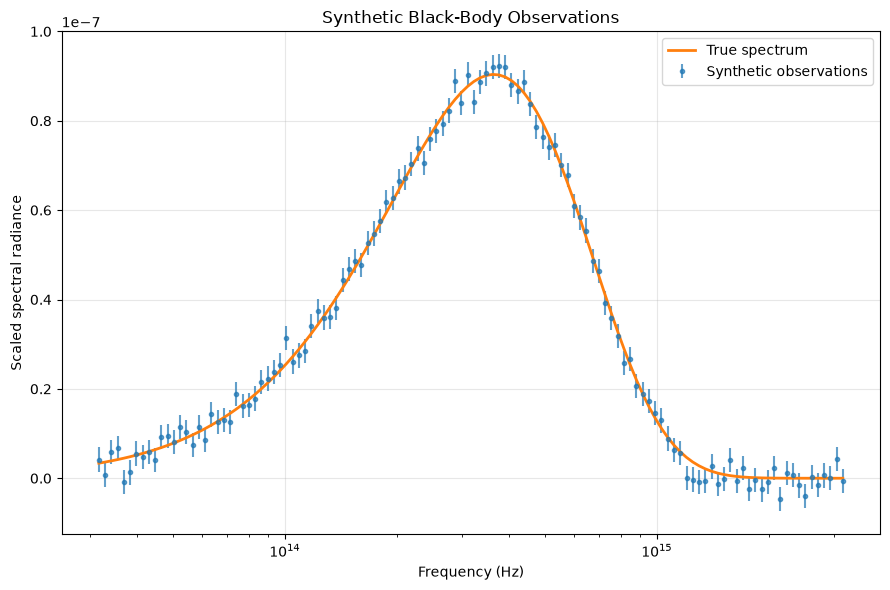

In [99]:
plt.figure(figsize=(9, 6))

plt.errorbar(
    observation_frequencies,
    observed_spectrum,
    yerr=observational_uncertainty,
    fmt="o",
    markersize=3,
    alpha=0.7,
    label="Synthetic observations",
)

plt.plot(
    observation_frequencies,
    true_spectrum,
    linewidth=2,
    label="True spectrum",
)

plt.xscale("log")

plt.xlabel("Frequency (Hz)")
plt.ylabel(r"Scaled spectral radiance")
plt.title("Synthetic Black-Body Observations")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [100]:
fit_result = fit_blackbody_spectrum(
    observation_frequencies,
    observed_spectrum,
    observational_uncertainty,
)

fitted_temperature = fit_result["temperature"]
temperature_uncertainty = fit_result[
    "temperature_uncertainty"
]

fitted_scale = fit_result["scale"]
scale_uncertainty = fit_result[
    "scale_uncertainty"
]


print(
    f"True temperature: "
    f"{true_temperature:.2f} K"
)

print(
    f"Recovered temperature: "
    f"{fitted_temperature:.2f} "
    f"+/- {temperature_uncertainty:.2f} K"
)

print(
    f"Temperature error: "
    f"{fitted_temperature - true_temperature:.2f} K"
)

print(
    f"Recovered scale: "
    f"{fitted_scale:.4f} "
    f"+/- {scale_uncertainty:.4f}"
)

True temperature: 6200.00 K
Recovered temperature: 6170.92 +/- 30.67 K
Temperature error: -29.08 K
Recovered scale: 2.0273 +/- 0.0322


In [101]:
fitted_spectrum = scaled_planck_radiance(
    observation_frequencies,
    fitted_scale,
    fitted_temperature,
)

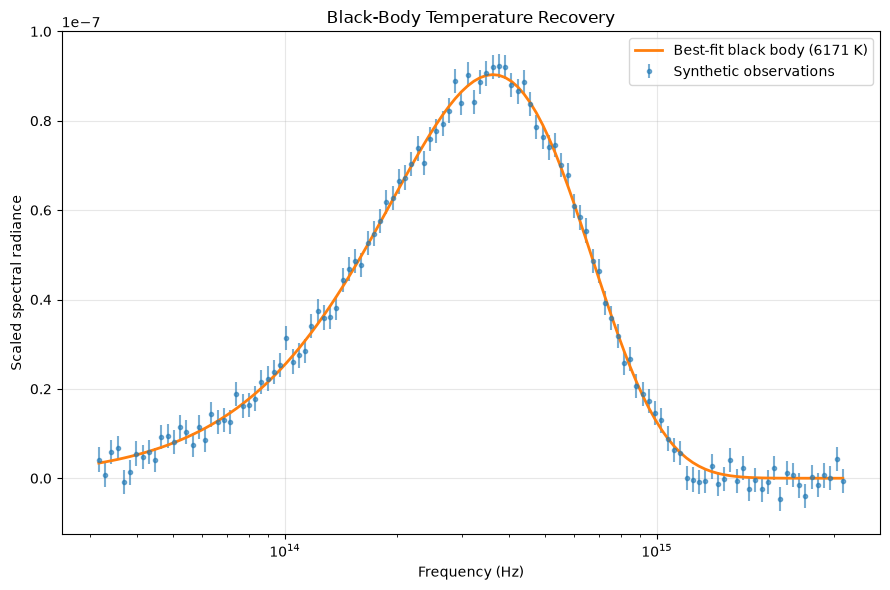

In [102]:
plt.figure(figsize=(9, 6))

plt.errorbar(
    observation_frequencies,
    observed_spectrum,
    yerr=observational_uncertainty,
    fmt="o",
    markersize=3,
    alpha=0.6,
    label="Synthetic observations",
)

plt.plot(
    observation_frequencies,
    fitted_spectrum,
    linewidth=2,
    label=(
        f"Best-fit black body "
        f"({fitted_temperature:.0f} K)"
    ),
)

plt.xscale("log")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Scaled spectral radiance")
plt.title("Black-Body Temperature Recovery")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "temperature_recovery.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [103]:
residuals = (
    observed_spectrum
    - fitted_spectrum
)

normalised_residuals = (
    residuals
    / observational_uncertainty
)

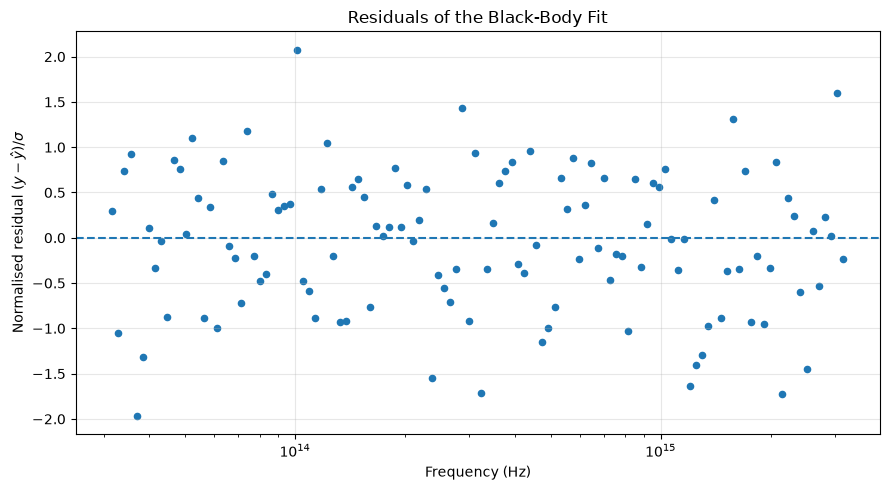

In [104]:
plt.figure(figsize=(9, 5))

plt.scatter(
    observation_frequencies,
    normalised_residuals,
    s=20,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xscale("log")

plt.xlabel("Frequency (Hz)")
plt.ylabel(r"Normalised residual $(y-\hat{y})/\sigma$")
plt.title("Residuals of the Black-Body Fit")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "fit_residuals.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [105]:
chi_squared = np.sum(
    normalised_residuals**2
)

degrees_of_freedom = (
    len(observed_spectrum) - 2
)

reduced_chi_squared = (
    chi_squared
    / degrees_of_freedom
)


print(
    f"Chi-squared: "
    f"{chi_squared:.2f}"
)

print(
    f"Degrees of freedom: "
    f"{degrees_of_freedom}"
)

print(
    f"Reduced chi-squared: "
    f"{reduced_chi_squared:.3f}"
)

Chi-squared: 72.84
Degrees of freedom: 118
Reduced chi-squared: 0.617


### Interpretation

The nonlinear fitting routine successfully recovers the temperature of the synthetic black-body source from noisy spectral measurements.

The recovered temperature is consistent with the known input temperature within the estimated fitting uncertainty. The residuals are distributed around zero without a strong systematic pattern, indicating that the fitted Planck model describes the synthetic observations well.

The reduced chi-squared statistic provides an additional measure of fit quality by comparing the residual scatter with the assumed observational uncertainties.

This exercise illustrates a simplified version of a common astrophysical inference problem: physical parameters are estimated by comparing noisy observational data with a theoretical spectral model.